< 파이토치 트랜스포머를 활용한 자연어 처리와 컴퓨터 비전 심층학습 >

# 7. 트랜스포머(p.357~387)


트랜스포머 기반 모델
  - 오토 인코딩(Auto-Encoding): 양방향의 토큰들을 참조해(인토더) 어떤 단어가 적절한지 예측하는 작업
  - 자기 회귀(Auto Regressive): 왼쪽에 있는 토큰들만 참조(단방향, 디코더)해 다음단어 맞히는 작업


#### **트래스포머**

: 딥러님 모델 중 하나로 어텐션 메커니즘만 사용해 시퀀스 임베딩 표현
  - 어텐션 메커니즘:인토더와 디코더 단어 사이의 상관관계를 계산해 중요 정보에 집중 --> 입력 단어가 출력의 어떤 단어와 관련이 있는지 파악, 번역 및 요약문 생성
    - 인코더: 입력 시퀀스를 임베딩해 고차원 벡터로 변환
    - 디코더: 인코더의 출력을 입력으로 받아 출력 시퀀스 생성
  - 병렬 처리 가능해 대규모 데이터셋에서 높은 성능. 문장의 전체정보 고려(길어도 성능 유지)
  - 인코더, 디코더는 각각 N개의 트랜스포머 블록으로 구성
    - 트랜스포머 블록: 멀티헤드 어텐션+순방향 신경망
    - 멀티헤드 어텐션: 입력에서 쿼리, 키, 값 벡터를 정의해 관계를 셀프 어텐션으로 함.(유사도를 가중치로 사용) --> 어텐션 행렬이 각 단어의 임베딩 벡터를 대체, 갱신
    - 순방향 신경망: 임베딩 벡터를 고도화
  
  - 인코더에서는 소스 시퀀스 데이터를 위치 인코딩된 입력 임베딩 표현, 디코더는 마스크 멀티헤드 어텐션을 사용해 타깃 시퀀스 데이터 순차적 생성




#### **입력 임베딩과 위치 인코딩**

- 입력 시퀀스의 각 단어는 임베딩 되어 벡터 형태로 변환, 병렬구조 처리이므로 순서 정보X --> 순서 정보를 반영하기 위해 위치 인코딩 방식 사용
  - 위치 인코딩: 각 단어의 임베딩 벡터+ 위치 정보 벡터를 더함. sim함수와 cos함수 사용해 위치 인코딩 벡터계산.


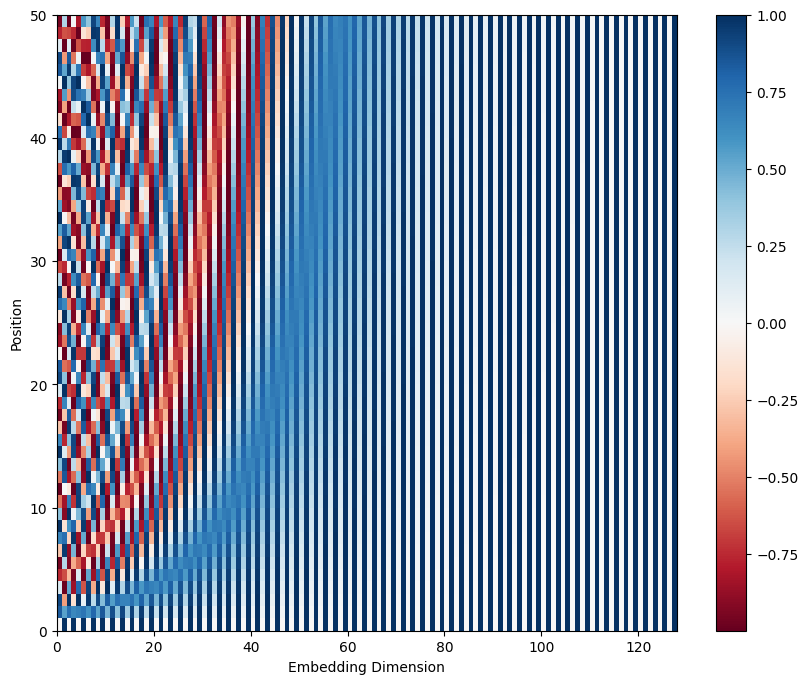

In [1]:
# 위치 인코딩
import math
import torch
from torch import nn
import matplotlib.pyplot as plt

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (seq_len, batch_size, d_model)
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)

# 모델 생성
encoding = PositionalEncoding(d_model=128, max_len=50)

plt.figure(figsize=(10, 8))
plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap="RdBu")
plt.xlabel("Embedding Dimension")
plt.xlim(0, 128)
plt.ylabel("Position")
plt.colorbar()
plt.show()

- pos는 입력 시퀀스에서 해당 단어의 위치를 나타냄, i는 임베딩 벡터의 차원 인덱스를 의미.각도 정보로 변환하기 위한 스케일링 인자로 주기적 신호 생성
- pe의 차원은 [최대 시퀀스, 1, 입력 임베딩 차원]: 위치별 임베딩 차원이 주기적인 값으로 구성됨.

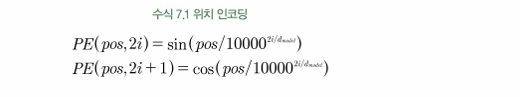

#### 특수 토큰

- 단어 토큰 외에 특수토큰을 활용해 문자 표현. 시작과 끝 또는 마스킹 영역에 사용
- 번역 모델에서는 이전 토큰만 참조하기 위해 현재위치 이후의 토큰 마스킹
- BOS: 문장의 시작 / EOS: 문장의 종료 / UNK: 모르는 단어 / PAD: 모든 문장을 일정한 길이로 맞추기 위해 빈공간에 사용
- 최종 문장 토큰 배열을 원핫인코딩으로 표현 -> 입력 임베딩으로 변환, 임베딩 텐서를 입력으로, 모든 계층에서 공유
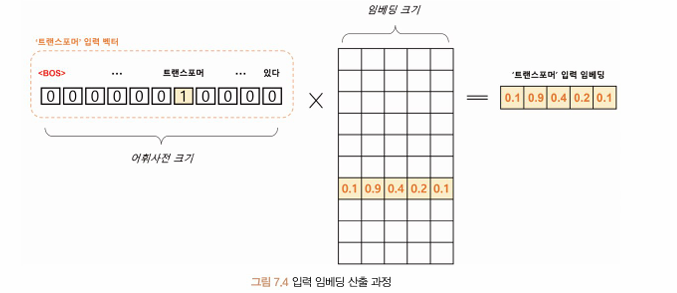

#### 트랜스포머 인코더

- 입력 시퀀스를 받아 여러 개의 인코더 계층을 거져 연산 수행, 각 인코더 계층은 멀티헤트 어텐션+순방향 신경망으로 구성
- 위치 인코딩 된 입력 임베딩 --> 3개의 임베딩 벡터 생성(Q, K, V)
  - Q: 현재 참고하고자 하는 정보의 위치 벡터. 현재 질문이 되는 벡터. 이 벡터를 기준으로 다은 시점의 정보 참조
  - K: Q벡터를 제외한 입력 시퀀스에서 탐색되는 벡터.
  - V: Q와 K로 생성된 어텐션 스코어를 얼마나 반영할지 설정하는 가중치

- 셀프 어텐션 스코어 맵 생성 --> 여러번 수행해 여러개의 헤드를 만들고 각 헤드의 어텐션의 결과를 합침 = 멀티헤드

- 마지막 인코더 블록에서 출력된 벡터는 디코더의 멀티헤드 어텐션 모듈에서 참조되는 키, 값 벡터로 활용



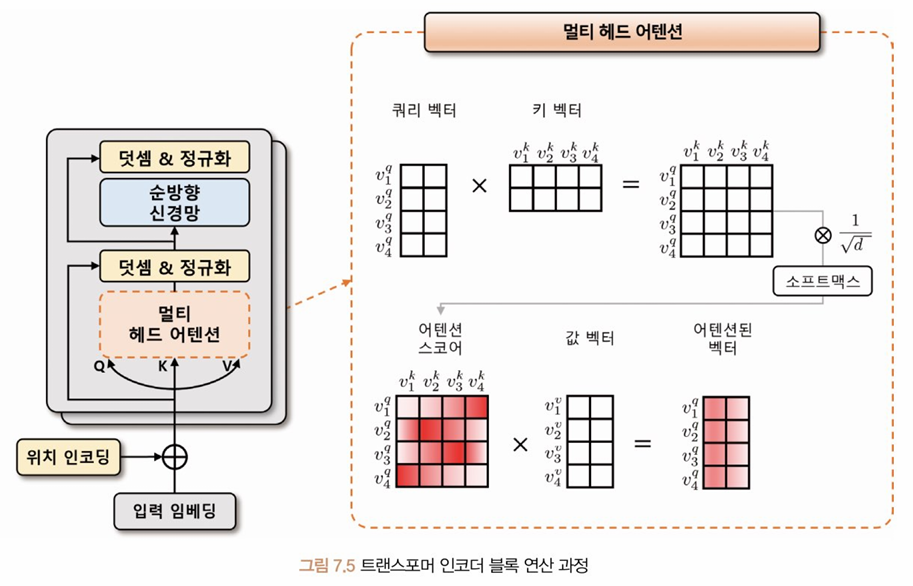

#### 트랜스포머 디코더

- 인코더의 멀티 헤드 어텐션 모듈 + 인과성 반영 -> 마스크 멀티 헤드 어텐션 모듈 : 현재 이전의 단어들만 참조가능.
   - 마스크 영역에 -inf 더해 해당영역의 어텐션 스코어값이 0에 가까워지도록 함
  - 타깃 데이터가 쿼리 벡터, 인코더의 소스 데이터가 키와 값 벳터
  - 멀티 헤드 어텐션은 인코더와 거의 동일하지만 셀프 어텐션 방지 위해 마스킹 적용
- 타깃 데이터를 추론할 때 토큰을 순차적으로 생성. 빈 값을 의미하는 PAD 토큰 사용

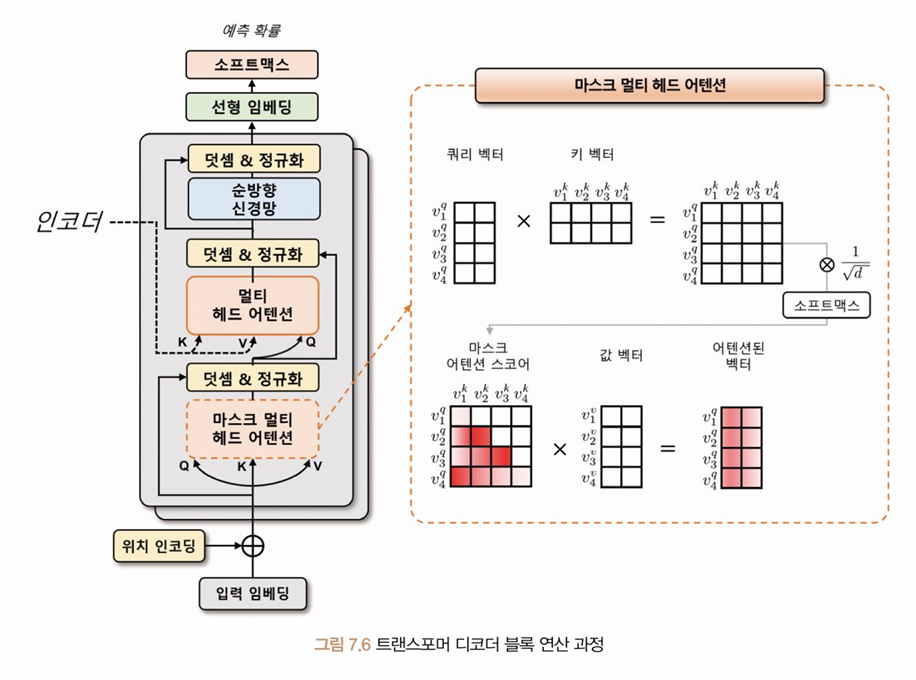

#### 모델 실습

영어-독일어 번역 모델 구성
- 대규모 다국어 데이터세트 Multo30k 사용


In [1]:
!pip install torch==2.3.0 torchtext==0.18.0 datasets transformers spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [2]:
!pip install datasets transformers spacy
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 28.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 113.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
from datasets import load_dataset  # 추가
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

SRC_LANGUAGE = 'de'
TGT_LANGUAGE = 'en'
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ['<unk>', '<pad>', '<bos>', '<eos>']

token_transform = {
    SRC_LANGUAGE: get_tokenizer('spacy', language='de_core_news_sm'),
    TGT_LANGUAGE: get_tokenizer('spacy', language='en_core_web_sm'),
}

def generate_tokens(text_iter, language):
    for text in text_iter:
        yield token_transform[language](text[language])

# Multi30k(split="train") 대신 Hugging Face에서 데이터를 가져옴
raw_dataset = load_dataset("bentrevett/multi30k")
train_data = list(raw_dataset['train'])

vocab_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language] = build_vocab_from_iterator(
        generate_tokens(train_data, language),
        min_freq=1,
        specials=special_symbols,
        special_first=True,
    )

for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language].set_default_index(UNK_IDX)

print("vocab Transform:")
print(vocab_transform)

/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated

README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

vocab Transform:
{'de': Vocab(), 'en': Vocab()}


In [3]:
# 트랜스포머 모델 구성
import math
import torch
from torch import nn
class PositionEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)
    position = torch.arange(max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2)*(-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(max_len, 1, d_model)
    pe[:, 0, 0::2] = torch.sin(position*div_term)
    pe[:, 0, 1::2] = torch.cos(position*div_term)
    self.register_buffer("pe",pe)

  def forward(self, x):
    x = x+self.pe[:x.size(0),:]
    return self.dropout(x)


class TokenEmbedding(nn.Module):
  def __init__(self, vocab_size, emb_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, emb_size)
    self.emb_size = emb_size

  def forward(self, tokens):
    return self.embedding(tokens.long())*math.sqrt(self.emb_size)


class Seq2SeqTransformer(nn.Module):
  def __init__(
      self,
      num_encoder_layers,
      num_decoder_layers,
      emb_size,
      max_len,
      nhead,
      src_vocab_size,
      tgt_vocab_size,
      dim_feedforward,
      dropout = 0.1,
  ):
    super().__init__()
    self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
    self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
    self.positional_encoding = PositionEncoding(
        d_model = emb_size, max_len = max_len, dropout=dropout
    )
    self.transformer = nn.Transformer(
        d_model = emb_size,
        nhead = nhead,
        num_encoder_layers = num_encoder_layers,
        num_decoder_layers= num_decoder_layers,
        dim_feedforward = dim_feedforward,
        dropout = dropout,
    )
    self.generator = nn.Linear(emb_size, tgt_vocab_size)

  def forward(
      self,
      src,
      trg,
      src_mask,
      tgt_mask,
      src_padding_mask,
      tgt_padding_mask,
      memory_key_padding_mask,
  ):
    src_emb = self.positional_encoding(self.src_tok_emb(src))
    tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
    outs = self.transformer(
        src = src_emb,
        tgt = tgt_emb,
        src_mask = src_mask,
        tgt_mask = tgt_mask,
        memory_mask = None,
        src_key_padding_mask = src_padding_mask,
        tgt_key_padding_mask = tgt_padding_mask,
        memory_key_padding_mask = memory_key_padding_mask
    )
    return self.generator(outs)

  def encode(self, src, src_mask):
    return self.transformer.encoder(
        self.positional_encoding(self.src_tok_emb(src)), src_mask
    )

  def decode(self, tgt, memory, tgt_mask):
    return self.transformer.decoder(
        self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
    )


In [4]:
# 트랜스포머 클래스
transformer = torch.nn.Transformer(
    d_model = 512,
    nhead = 8,
    num_encoder_layers = 6,
    num_decoder_layers = 6,
    dim_feedforward = 2048,
    dropout = 0.1,
    activation = torch.nn.functional.relu,
    layer_norm_eps =1e-05
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [5]:
# # 트랜스포머 순방향 메서드
# output = transformer.forward(
#     src,
#     tgt,
#     src_mask = None,
#     tgt_mask = None,
#     memory_mask = None,
#     src_key_padding_mask = None,
#     tgt_key_padding_mask= None,
#     memory_key_padding_mask= None,
# )

In [6]:
# 트랜스포머 모델 구조
from torch import optim

BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead = 8,
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),
    dim_feedforward = 512,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
  print(main_name)
  for sub_name, sub_module in main_module.named_children():
    print("L", sub_name)
    for ssub_name, ssub_module in sub_module.named_children():
      print("| L", ssub_name)
      for sssub_name, sssub_module in ssub_module.named_children():
        print("| | L", sssub_name)

src_tok_emb
L embedding
tgt_tok_emb
L embedding
positional_encoding
L dropout
transformer
L encoder
| L layers
| | L 0
| | L 1
| | L 2
| L norm
L decoder
| L layers
| | L 0
| | L 1
| | L 2
| L norm
generator


In [7]:
# 배치 데이터 생성
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

def input_transform(token_ids):
    return torch.cat(
        (torch.tensor([BOS_IDX]), torch.tensor(token_ids), torch.tensor([EOS_IDX]))
    )

def collator(batch):
    src_batch, tgt_batch = [], []
    for sample in batch:
        src_sample = sample[SRC_LANGUAGE]
        tgt_sample = sample[TGT_LANGUAGE]
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))

    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch

text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    text_transform[language] = sequential_transforms(
        token_transform[language], vocab_transform[language], input_transform
    )

data_iter = raw_dataset['validation']
dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)

source_tensor, target_tensor = next(iter(dataloader))

print("(source, target):")
print(data_iter)

print("\nsource_batch shape:", source_tensor.shape)
print(source_tensor)

(source, target):
Dataset({
    features: ['en', 'de'],
    num_rows: 1014
})

source_batch shape: torch.Size([35, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  14,    5,    5,  ...,    5,   21,    5],
        [  38,   12,   35,  ...,   12, 1750,   69],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])


In [8]:
# 어텐션 마스크 생성
def generate_square_subsequent_mask(s):
    mask = (torch.triu(torch.ones((s, s), device=DEVICE)) == 1).transpose(0, 1)
    mask = (
        mask.float()
        .masked_fill(mask == 0, float('-inf'))
        .masked_fill(mask == 1, float(0.0))
    )
    return mask


def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)

    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask


target_input = target_tensor[:-1, :]
target_out = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor, target_input
)


print("source_mask:", source_mask.shape)
print(source_mask)

print("target_mask:", target_mask.shape)
print(target_mask)

print("source_padding_mask:", source_padding_mask.shape)
print(source_padding_mask)

print("target_padding_mask:", target_padding_mask.shape)
print(target_padding_mask)

source_mask: torch.Size([35, 35])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='cuda:0')
target_mask: torch.Size([29, 29])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf,

In [9]:
# 모델 학습 및 평가
def run(model, optimizer, criterion, split):
    model.train() if split == "train" else model.eval()

    ds_split = "validation" if split == "valid" else split
    data_iter = raw_dataset[ds_split]
    dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)

    losses = 0

    for source_batch, target_batch in dataloader:
        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        target_input = target_batch[:-1, :]
        target_output = target_batch[1:, :]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(
            source_batch, target_input
        )

        logits = model(
            src=source_batch,
            trg=target_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )

        optimizer.zero_grad()
        loss = criterion(logits.reshape(-1, logits.shape[-1]), target_output.reshape(-1))

        if split == "train":
            loss.backward()
            optimizer.step()

        losses += loss.item()

    return losses / len(dataloader)

for epoch in range(5):
    train_loss = run(model, optimizer, criterion, "train")
    val_loss = run(model, optimizer, criterion, "valid")
    print(f"Epoch: {epoch+1}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch: 1, Train loss: 4.885, Val loss: 4.220
Epoch: 2, Train loss: 3.929, Val loss: 3.785
Epoch: 3, Train loss: 3.574, Val loss: 3.616
Epoch: 4, Train loss: 3.388, Val loss: 3.567
Epoch: 5, Train loss: 3.250, Val loss: 3.537


In [10]:
# 모델 번역 결과
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)

    memory = model.encode(source_tensor, source_mask)

    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)

    for i in range(max_len - 1):
        memory = memory.to(DEVICE)

        target_mask = generate_square_subsequent_mask(ys.size(0))
        target_mask = target_mask.type(torch.bool).to(DEVICE)

        out = model.decode(ys, memory, target_mask)
        out = out.transpose(0, 1)

        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(source_tensor.data).fill_(next_word)],
            dim=0
        )

        if next_word == EOS_IDX:
            break

    return ys


def translate(model, source_sentence):
    model.eval()

    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)

    num_tokens = source_tensor.shape[0]

    source_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)

    target_tokens = greedy_decode(
        model,
        source_tensor,
        source_mask,
        max_len=num_tokens + 5,
        start_symbol=BOS_IDX
    ).flatten()

    output = vocab_transform[TGT_LANGUAGE].lookup_tokens(
        list(target_tokens.cpu().numpy())
    )[1:-1]

    return " ".join(output)


output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude.")
print(output)

A group of people are sitting on a bench .
